<a href="https://colab.research.google.com/github/hmmnyamminji/python/blob/main/Chapter05_02_%EC%BA%90%EA%B8%80%EC%A3%BC%ED%83%9D%EA%B0%80%EA%B2%A9_%ED%9A%8C%EA%B7%80%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving NanumGothic.ttf to NanumGothic (1).ttf


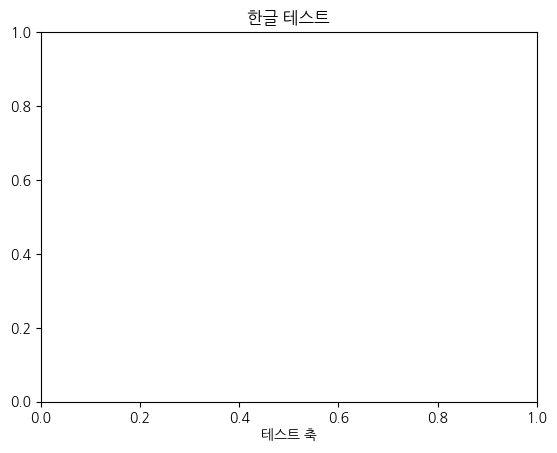

In [35]:
# 구글 드라이브 마운트
from google.colab import drive, files
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트를 관리하는 모듈
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew


import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor # XGBoost 회귀용 클래스
from lightgbm import LGBMRegressor # LightGBM 회귀용 클래스

In [16]:
# 데이터 로딩 및 기본 탐색 (EDA)

# 캐글 House Prices 데이터셋, 미국 아이오와주 에임스(Ames) 지역 주택 거래 데이터
house_df_org = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/house_prices/train-2.csv')

house_df = house_df_org.copy()

print('데이터 크기:', house_df.shape) # id + 79개 피처 + ScalePrice
print('\n피처 타입 분포:')
print(house_df.dtypes.value_counts())
isnull_series = house_df.isnull().sum()
print('\n결측치 많은 컬럼 (상위 10개):')
print(isnull_series[isnull_series > 0].sort_values(ascending=False).head(10))

데이터 크기: (1460, 81)

피처 타입 분포:
object     43
int64      35
float64     3
Name: count, dtype: int64

결측치 많은 컬럼 (상위 10개):
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64


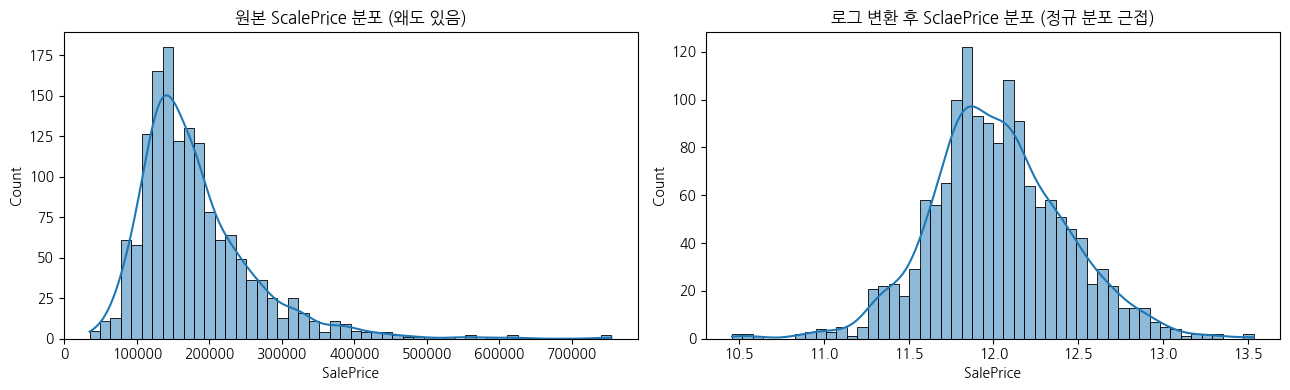

In [13]:
# ScalePrice 분포 확인 및 로그 변환 필요성 검토
# 선형 회귀는 종속변수 (ScalePrice)가 정규 분포에 가까울수록 성능 좋음
fig, axes = plt.subplots(1,2, figsize=(13, 4))

axes[0].set_title('원본 ScalePrice 분포 (왜도 있음)')
sns.histplot(house_df['SalePrice'], bins=50, kde=True, ax=axes[0])

axes[1].set_title('로그 변환 후 SclaePrice 분포 (정규 분포 근접)')
sns.histplot(np.log1p(house_df['SalePrice']), bins=50, kde=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [18]:
# STEP 1: 전처리 - 로그 변환 + 결측치 처리 + 원-핫 인코딩
# [전처리 순서가 중요한 이유]
#   1. SalePrice 로그 변환 (모델 가정 충족)
#   2. 결측치 처리 (모델이 NaN 처리 못함)
#   3. 원-핫 인코딩 (문자형을 수치형으로 변환)

house_df['SalePrice'] = np.log1p(house_df['SalePrice'])
house_df.drop(
    ['Id', 'PoolQC','MiscFeature','Alley','Fence','FireplaceQu'],
    axis=1, inplace=True, errors='ignore'
)
numerical_cols = house_df.select_dtypes(include=np.number).columns
house_df[numerical_cols] = house_df[numerical_cols].fillna(house_df[numerical_cols].mean()) # 각 컬럼별로 평균값이 결측치로 대체

null_cols = house_df.isnull().sum()[house_df.isnull().sum() > 0]
print('남은 결측 컬럼 타입:\n', house_df.dtypes[null_cols.index])

남은 결측 컬럼 타입:
 MasVnrType      object
BsmtQual        object
BsmtCond        object
BsmtExposure    object
BsmtFinType1    object
BsmtFinType2    object
Electrical      object
GarageType      object
GarageFinish    object
GarageQual      object
GarageCond      object
dtype: object


In [20]:
# STEP 2: 원-핫 인코딩(One-Hot Encoding)
# pd.get_dummies vs sklearn OneHotEncoder
# get_dummies는 결측값(NaN)을 0으로 처리, 전체 데이터를 한 번에 변환, 학습/테스트 분리 후 컬럼 수 불일치 주의
print('get_dummies() 전 shape:', house_df.shape)

house_df_ohe = pd.get_dummies(house_df)
print('get_dummies() 후 shape:', house_df_ohe.shape)
null_cols = house_df_ohe.isnull().sum()[house_df_ohe.isnull().sum() > 0]
print(len(null_cols))

get_dummies() 전 shape: (1460, 75)
get_dummies() 후 shape: (1460, 270)
0


In [21]:
# 선형 회귀 모델 학습/예측/평가

# 학습/테스트 분리
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=156
)
print('학습셋:', X_train.shape, '테스트셋:', X_test.shape)

학습셋: (1168, 269) 테스트셋: (292, 269)


In [30]:
def get_rmse(model):
  pred = model.predict(X_test)
  mse = mean_squared_error(y_test, pred)
  rmse = np.sqrt(mse)
  print(f"{model.__class__.__name__} RMSE: {rmse:.4f}")
  return rmse

def get_rmses(models):
  return [get_rmse(model) for model in models]

In [29]:
#LinearRegression , Ridge, Lasso 기본 학습
lr_reg = LinearRegression()
ridge_reg = Ridge()
lasso_reg = Lasso()

lr_reg.fit(X_train, y_train)
ridge_reg.fit(X_train, y_train)
lasso_reg.fit(X_train, y_train)

print('기본 하이퍼 파라미터 RMSE')
models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

기본 하이퍼 파라미터 RMSE


[np.float64(0.010481899993240706),
 np.float64(0.00997580081727198),
 np.float64(0.01795924469011488)]

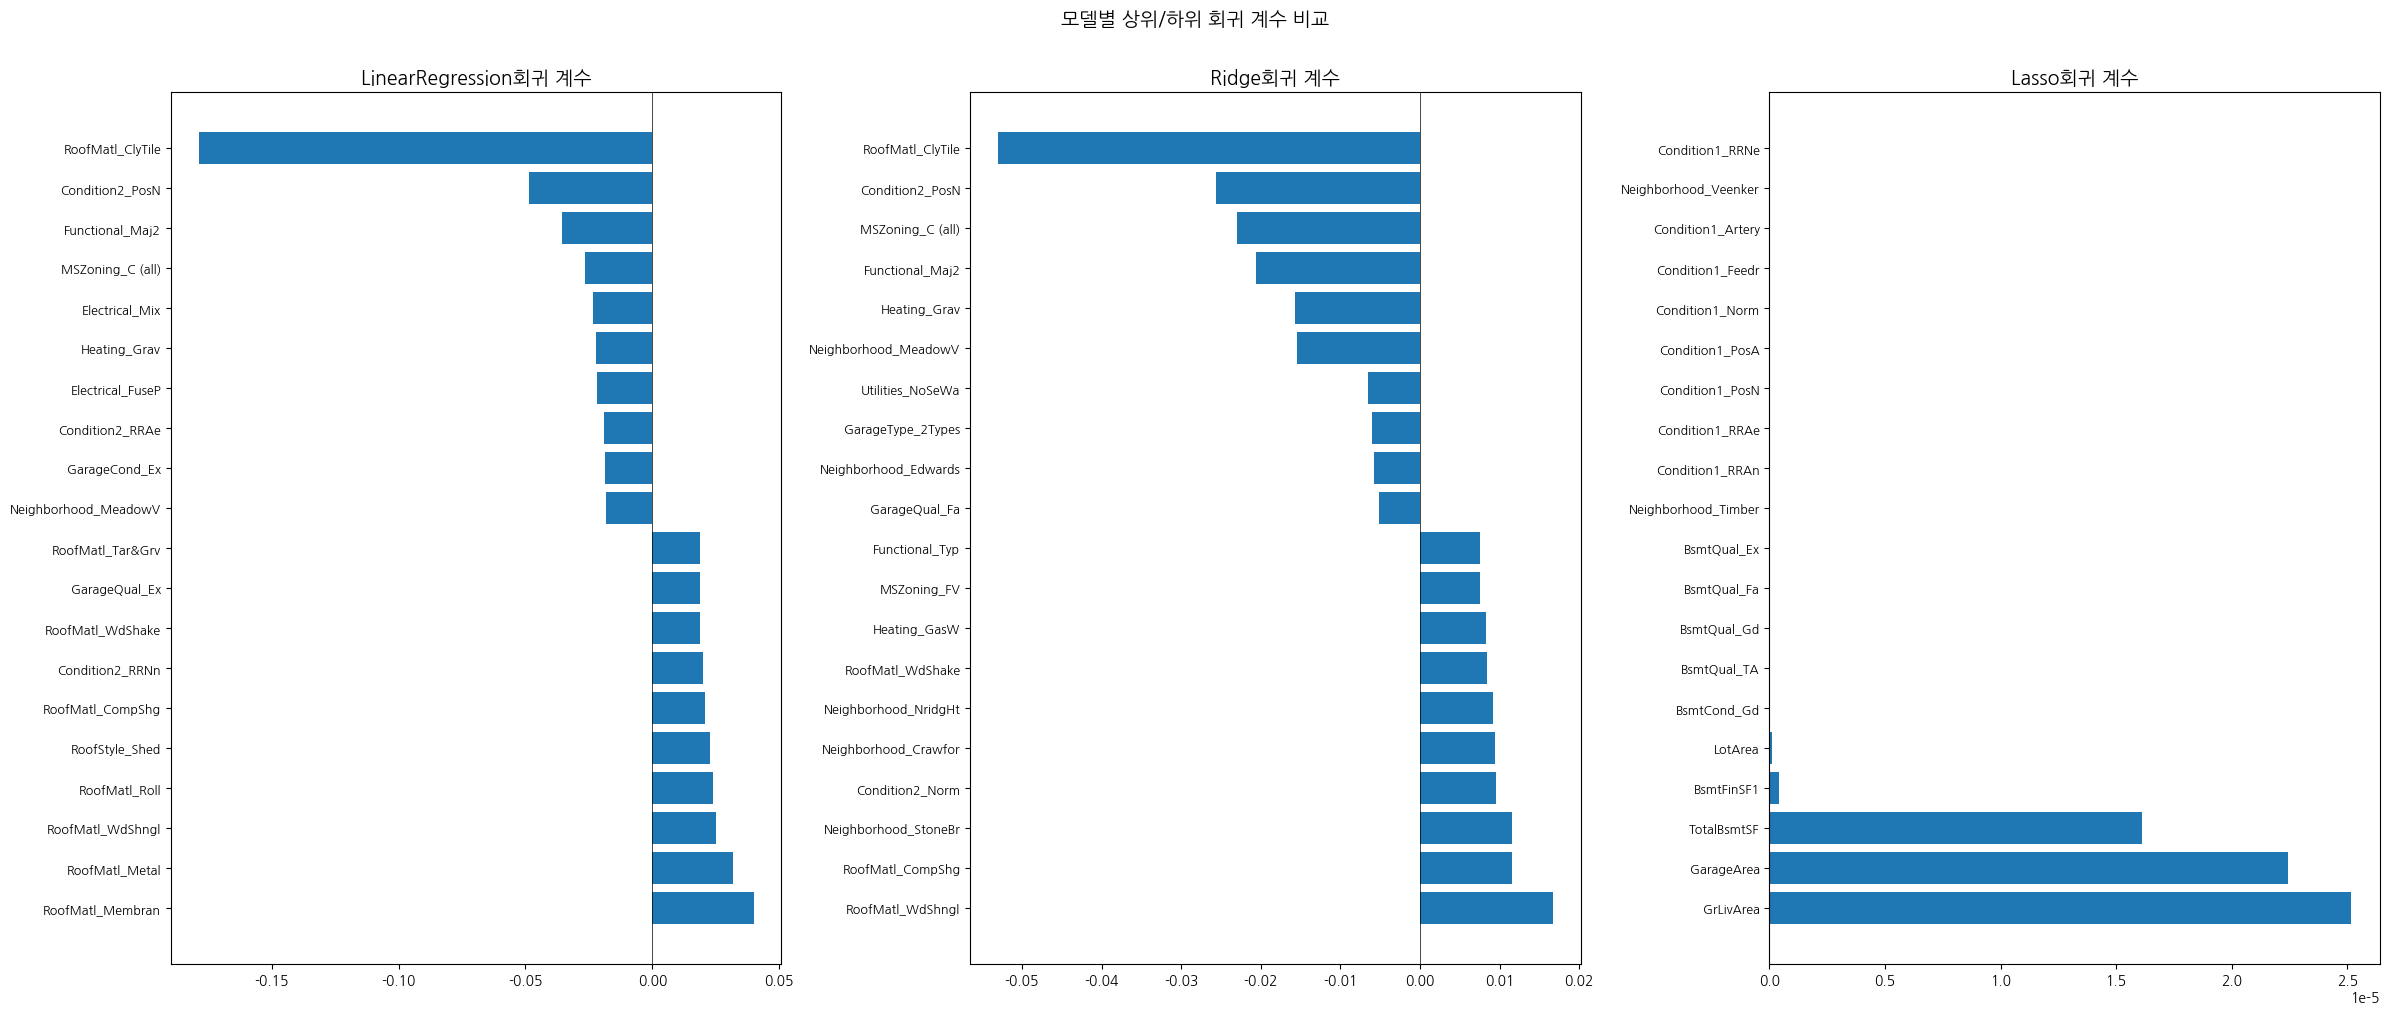

In [33]:
# 상위 10개(양의 영향) 하위 10개(음의 영향)회귀 계수 추출
def get_top_bottom_coef(model):
  coef = pd.Series(model.coef_, index=X_features.columns) # 각 컬럼의
  coef_high = coef.sort_values(ascending=False).head(10)
  coef_low = coef.sort_values(ascending=False).tail(10)
  return coef_high, coef_low

# 회귀 계수 시각화 함수
def visualize_coefficient(models):
  fig, axs = plt.subplots(figsize=(24, 10), nrows=1, ncols=3)
  for i, model in enumerate(models):
    coef_high, coef_low = get_top_bottom_coef(model)
    coef_concat = pd.concat([coef_high, coef_low]) # 하나의 Series로 합침
    axs[i].set_title(f'{model.__class__.__name__}회귀 계수', size=14)
    axs[i].tick_params(axis='y', labelsize=9)
    axs[i].barh(coef_concat.index, coef_concat.values)
    axs[i].axvline(0, color='black', linewidth=0.5)
  plt.suptitle('모델별 상위/하위 회귀 계수 비교', fontsize=14, y=1.01)
  fig.tight_layout()
  plt.show()

visualize_coefficient(models)

In [37]:
# 5-Fold 교차 검증 RMSE 비교
def get_avg_rmse_cv(models):
  for model in models:
    rmse_list = np.sqrt(-cross_val_score(
        model, X_features, y_target,
        scoring='neg_mean_squared_error',
        cv=5))
    print(f'{model.__class__.__name__} CV RMSE: {np.round(rmse_list, 43)} 평균: {np.round(np.mean(rmse_list), 3)}')



print('5-Fold 교착 검증 RMSE')
get_avg_rmse_cv([lr_reg, ridge_reg, lasso_reg])
# 5개 폴드 RMSE가 비슷하면 안정적, 차이가 크면 불안정한 모델

5-Fold 교착 검증 RMSE
LinearRegression CV RMSE: [0.01054658 0.01286038 0.01300613 0.0087821  0.01511643] 평균: 0.012
Ridge CV RMSE: [0.00918378 0.01200632 0.01105914 0.00916823 0.01442677] 평균: 0.011
Lasso CV RMSE: [0.01614689 0.01894624 0.01773087 0.01744697 0.02248829] 평균: 0.019


In [40]:
# GridSearchCV로 최적 alpha 탐색
ridge_params = {'alpha': [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha': [0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]} #L1 규제는 계수를 0으로 만드는 힘 강함

def print_best_params(model, params):
  grid_model = GridSearchCV(
      model, param_grid=params,
      scoring='neg_mean_squared_error', cv=5
  )
  grid_model.fit(X_features, y_target)
  rmse = np.sqrt(-1 * grid_model.best_score_)
  print(f'{model.__class__.__name__} 5-CV 최적 RMSE: {rmse:.4f} 최적파라미터: {grid_model.best_params_}')
  return grid_model.best_estimator_ # 최적 파라미터로 학습된 모델 반환

best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

Ridge 5-CV 최적 RMSE: 0.0110 최적파라미터: {'alpha': 10}
Lasso 5-CV 최적 RMSE: 0.0126 최적파라미터: {'alpha': 0.001}


[최적 alpha 적용 후] RMSE
LinearRegression RMSE: 0.0105
Ridge RMSE: 0.0097
Lasso RMSE: 0.0114


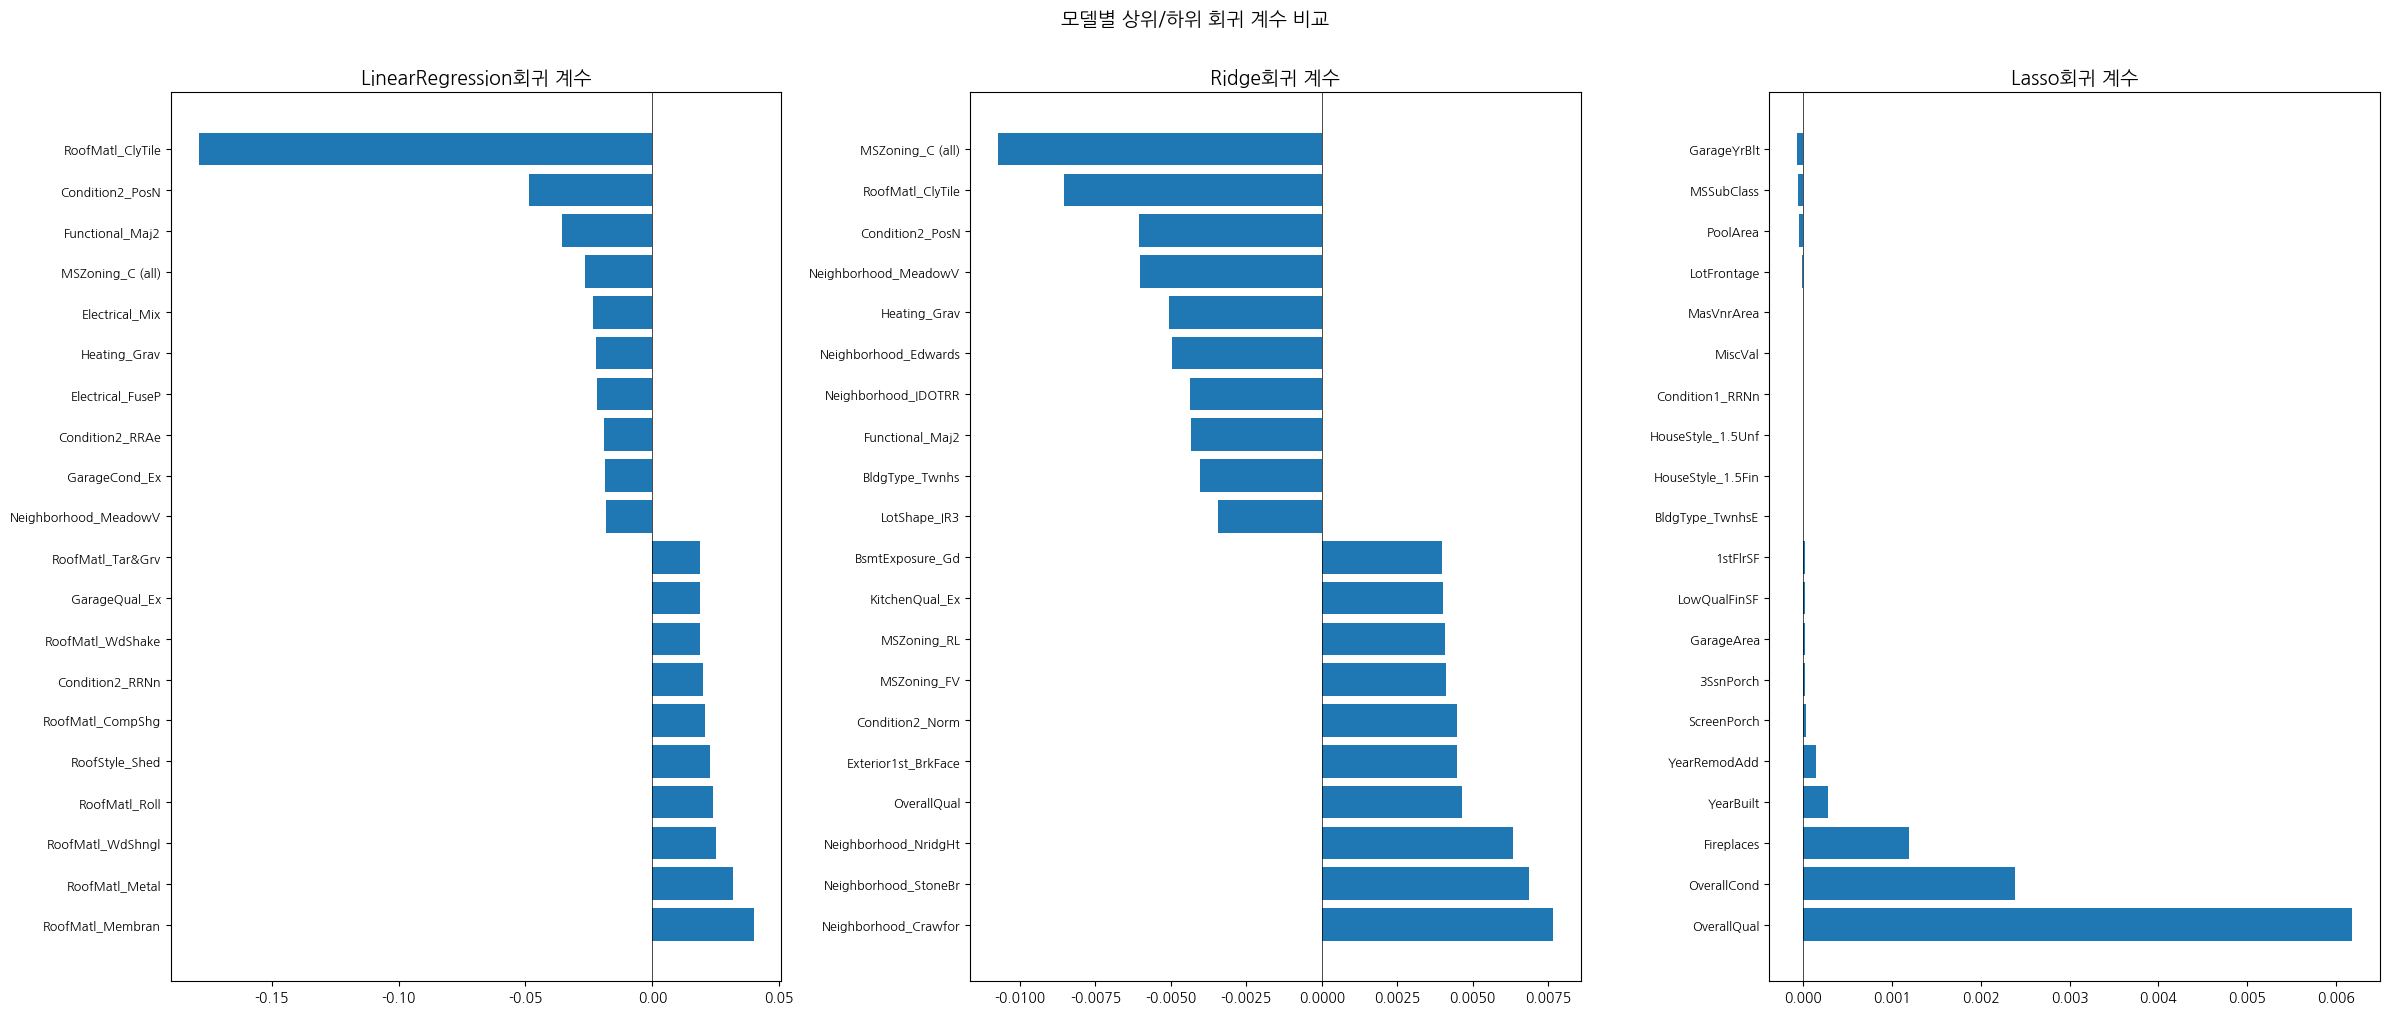

In [42]:
# 최적 alpha로 재학습 및 성능 평가
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10) # 최적 alpha로 변경
lasso_reg = Lasso(alpha=0.001) # 최적 alpha로 변경

for model in [lr_reg, ridge_reg, lasso_reg]:
  model.fit(X_train, y_train)
print('[최적 alpha 적용 후] RMSE')
get_rmses([lr_reg, ridge_reg, lasso_reg]) # get_rmse 대신 get_rmses 사용, set 대신 list 전달
# 최적 alpha 적용 후 계수 분포 재확인
visualize_coefficient([lr_reg, ridge_reg, lasso_reg]) # set 대신 list 전달

In [53]:
# 수치형 피처의 왜도 (Skewness) 분석
features_index = house_df.dtypes[house_df.dtypes != 'object'].index # 수치형 칼럼만 선택
skew_features = house_df[features_index].apply(lambda x: skew(x)) # 각 수치형 칼럼에 .skew() 적용
skew_features_top = skew_features[skew_features > 1]             # 왜도 1 이상인 피처만 필터링
print('왜도 > 1인 피처 목록 (내림차순): ')
print(skew_features_top.sort_values(ascending=False))

왜도 > 1인 피처 목록 (내림차순): 
PoolArea         14.348342
3SsnPorch         7.727026
LowQualFinSF      7.452650
MiscVal           5.165390
BsmtHalfBath      3.929022
KitchenAbvGr      3.865437
ScreenPorch       3.147171
BsmtFinSF2        2.521100
EnclosedPorch     2.110104
dtype: float64


In [54]:
# 왜도 높은 피처 로그 변환 후 전체 파이프라인 재실행
house_df[skew_features_top.index] = np.log1p(house_df[skew_features_top.index])
house_df_ohe = pd.get_dummies(house_df) # 로그 변환 후 원-핫 인코딩 재적용

# 학습/테스트 분리 (동일 random_state로 공정 비교)
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=156
)

# 왜도 처리 후 최적 alpha 재탐색
best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

Ridge 5-CV 최적 RMSE: 0.0099 최적파라미터: {'alpha': 10}
Lasso 5-CV 최적 RMSE: 0.0122 최적파라미터: {'alpha': 0.001}


[왜도 처리 후] RMSE
LinearRegression RMSE: 0.0101
Ridge RMSE: 0.0095
Lasso RMSE: 0.0120


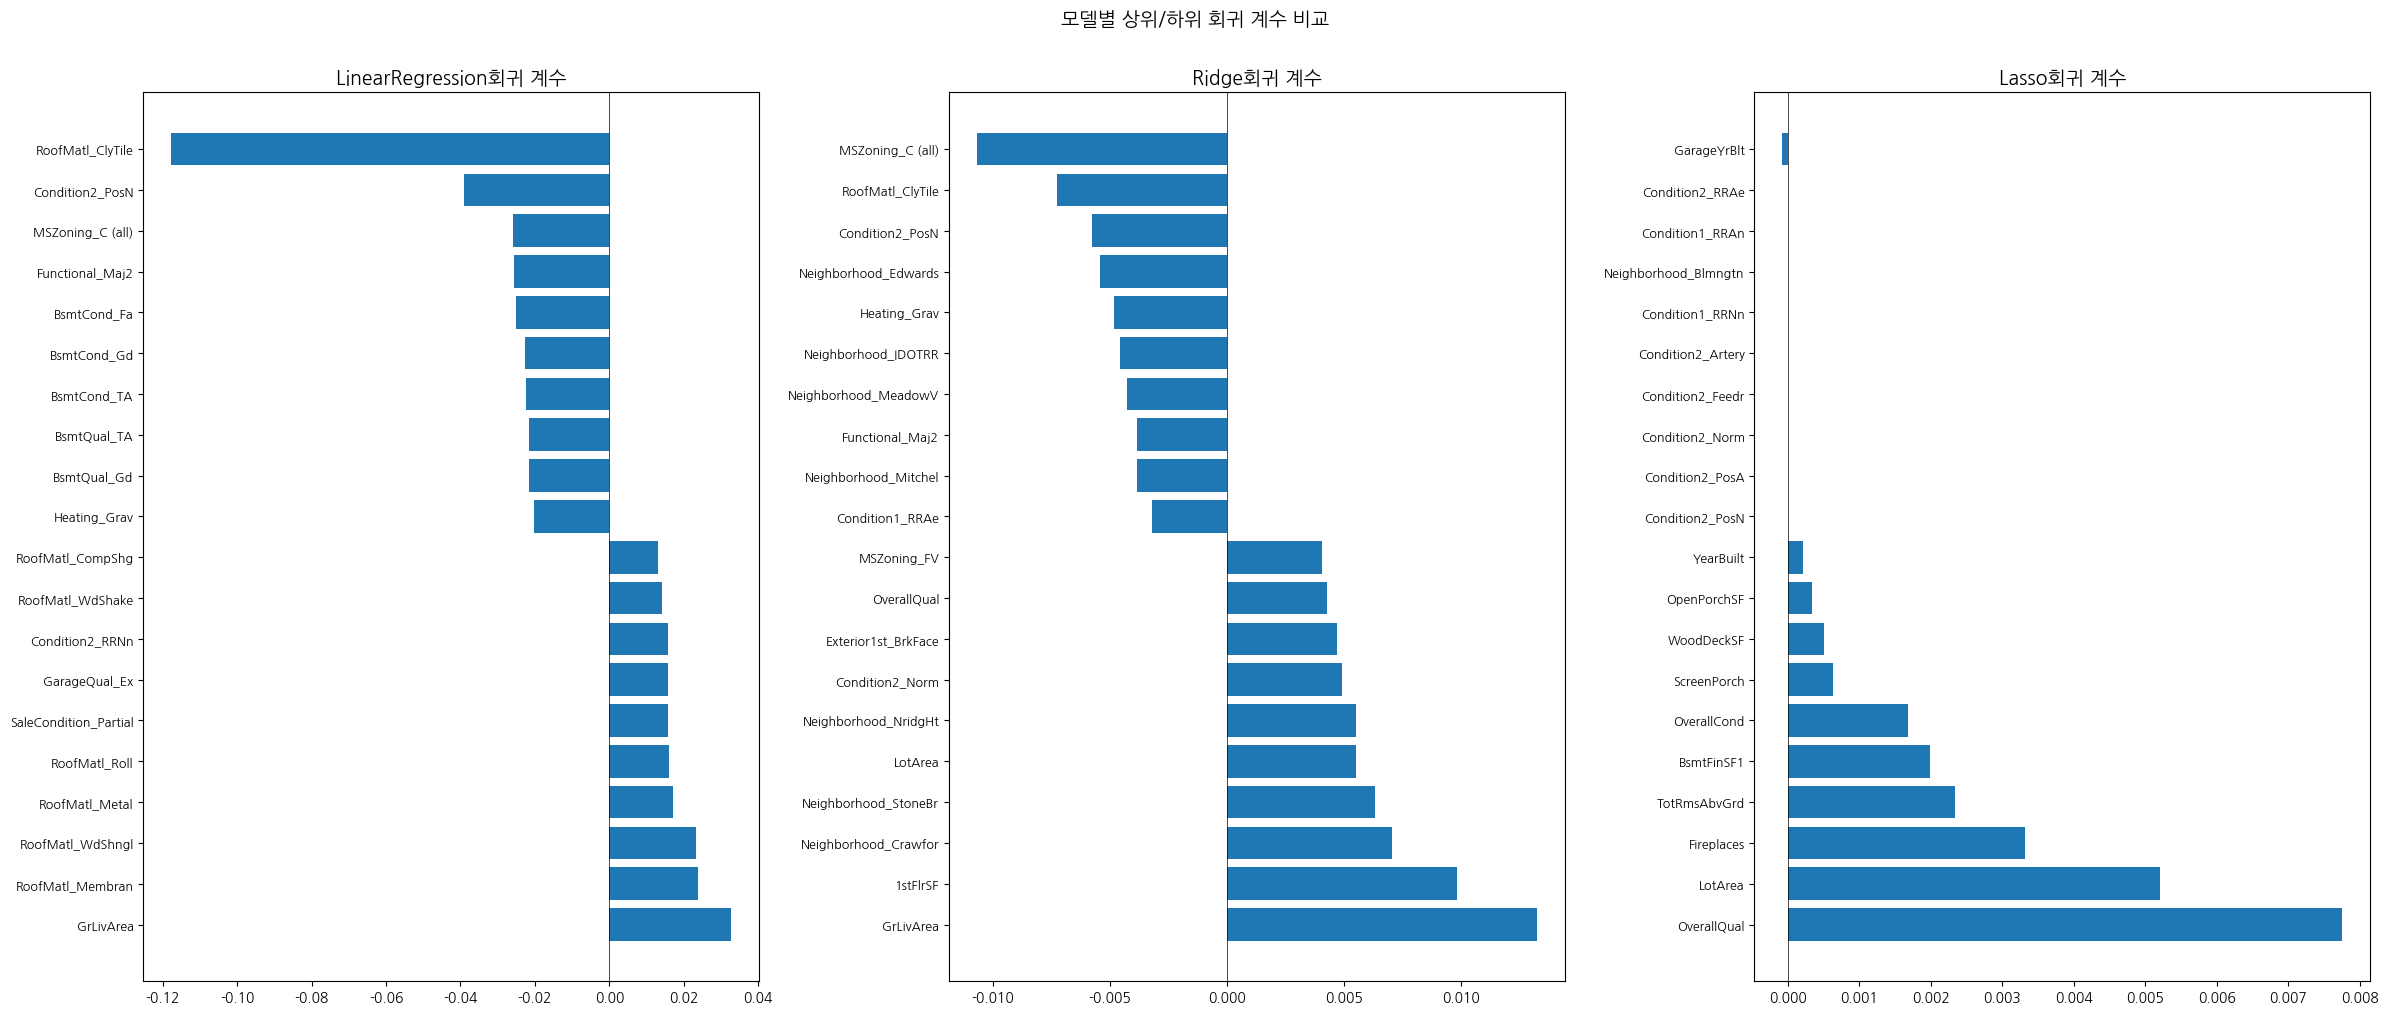

In [50]:
# 왜도 처리 후 최적 파라미터로 재학습 및 평가
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.001)

for model in [lr_reg, ridge_reg, lasso_reg]:
  model.fit(X_train, y_train)
print('[왜도 처리 후] RMSE')
get_rmses([lr_reg, ridge_reg, lasso_reg])
# 최적 alpha 적용 후 계수 분포 재확인
visualize_coefficient([lr_reg, ridge_reg, lasso_reg]) # set 대신 list 전달

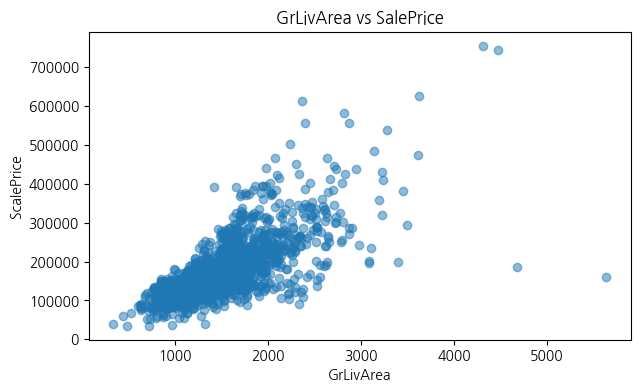

In [55]:
# 이상치(Outlier) 탐지: GrLivArea vs SalePrice 산점도
# 선형 회귀는 최소제곱법(MSE 최소화) -> 이상치에 민감, 이상치 하나가 회귀선 전체를 왜곡 가능
plt.figure(figsize=(7,4))
plt.scatter(
    x=house_df_org['GrLivArea'],
    y=house_df_org['SalePrice'],
    alpha=0.5
)
plt.ylabel('ScalePrice')
plt.xlabel('GrLivArea')
plt.title('GrLivArea vs SalePrice')
plt.show()

In [60]:
# 이상치 제거
cond1 = house_df_ohe['GrLivArea'] > np.log1p(4000)
cond2 = house_df_ohe['SalePrice'] < np.log1p(50000)
outlier_index = house_df_ohe[cond1 & cond2].index

print('이상치 레코드 인덱스:', outlier_index.values)
print('이상치 삭제 전:', house_df_ohe.shape)
house_df_ohe.drop(outlier_index, axis=0, inplace=True)
print('이상치 삭제 후:', house_df_ohe.shape)

이상치 레코드 인덱스: [ 523  691 1182 1298]
이상치 삭제 전: (1460, 270)
이상치 삭제 후: (1456, 270)


Ridge 5-CV 최적 RMSE: 0.0099 최적파라미터: {'alpha': 10}
Lasso 5-CV 최적 RMSE: 0.0122 최적파라미터: {'alpha': 0.001}
[이상치 제거 후] RMSE
LinearRegression RMSE: 0.0101
Ridge RMSE: 0.0094
Lasso RMSE: 0.0120


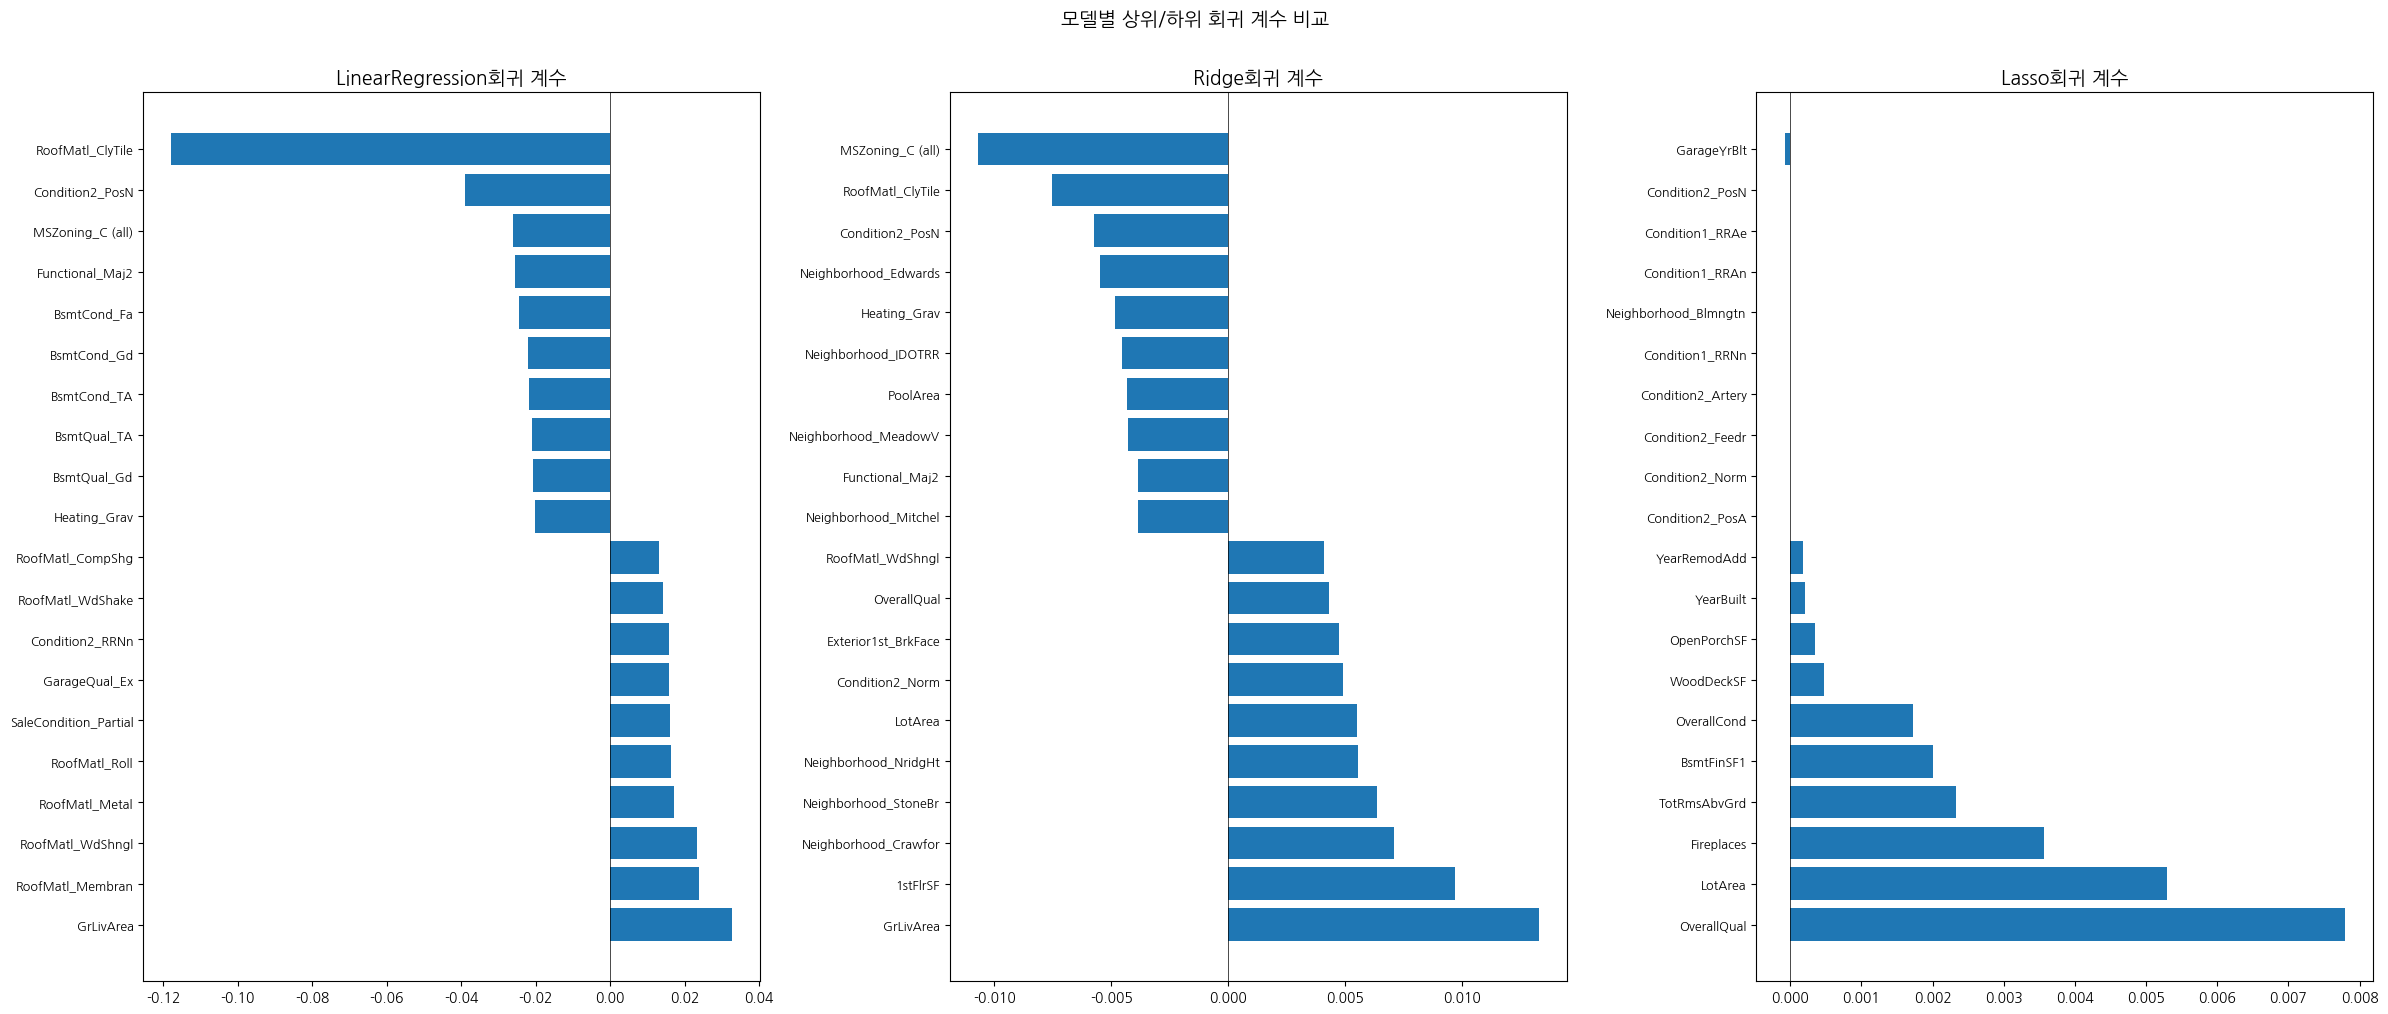

In [58]:
# 이상치 제거 후 재분리 + 최종 선형 모델 평가


# 학습/테스트 분리 (동일 random_state로 공정 비교)
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=156
)

# 왜도 처리 후 최적 alpha 재탐색
best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.001)

for model in [lr_reg, ridge_reg, lasso_reg]:
  model.fit(X_train, y_train)

print('[이상치 제거 후] RMSE')
get_rmses([lr_reg, ridge_reg, lasso_reg])
# 최적 alpha 적용 후 계수 분포 재확인
visualize_coefficient([lr_reg, ridge_reg, lasso_reg])